In [49]:
import pandas as pd
import glob
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [63]:
lambert_TFs = pd.read_csv("../output/lambert_TFs_LOEUF_group_info.csv")
#lambert_TFs = lambert_TFs[["transcript", "repressor", "activator", "sfari"]]
lambert_TFs
# SFARI_genes = pd.read_csv("../data/SFARI-Gene_genes_01-23-2023release_03-21-2023export.csv")
# SFARI_TFs = lambert_TFs[lambert_TFs["gene_id"].isin(SFARI_genes["ensembl-id"])]
# SFARI_TFs

,Unnamed: 0,gene_id,gene,From,Entry,Gene Names (primary),LOEUF,transcript,repressor,activator,sfari
0,0,ENSG00000137203,TFAP2A,TFAP2A,P05549,TFAP2A,0.334,ENST00000379613,False,True,False
1,1,ENSG00000008196,TFAP2B,TFAP2B,Q92481,TFAP2B,0.353,ENST00000393655,True,True,False
2,2,ENSG00000087510,TFAP2C,TFAP2C,Q92754,TFAP2C,0.417,ENST00000201031,True,True,False
3,3,ENSG00000008197,TFAP2D,TFAP2D,Q7Z6R9,TFAP2D,0.389,ENST00000008391,False,True,False
4,4,ENSG00000116819,TFAP2E,TFAP2E,Q6VUC0,TFAP2E,1.418,ENST00000373235,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1658,1658,ENSG00000177683,THAP5,THAP5,Q7Z6K1,THAP5,1.089,ENST00000415914,True,False,False
1659,1659,ENSG00000174796,THAP6,THAP6,Q8TBB0,THAP6,1.028,ENST00000311638,True,False,False
1660,1660,ENSG00000184436,THAP7,THAP7,Q9BT49,THAP7,1.147,ENST00000215742,True,False,False
1661,1661,ENSG00000161277,THAP8,THAP8,Q8NA92,THAP8,1.615,ENST00000292894,True,False,False


In [40]:
domain_mtr = []

ENSTs = glob.glob("../soto_analysis/outputs/mutations/domains_mtr/*")

for ENST in ENSTs:
    try:
        df = pd.read_csv(ENST, sep = "\t", header = None)
        domain_mtr.append(df)
    except pd.errors.EmptyDataError:
        print(ENST, " is empty and has been skipped.")

domain_mtr = pd.concat(domain_mtr)
domain_mtr = domain_mtr.rename(columns = {7: "ENST", 16: "MTR"})
dbd_mtr = domain_mtr[domain_mtr[3] == "DBD"]
ad_mtr = domain_mtr[domain_mtr[3] == "AD"]
rd_mtr = domain_mtr[domain_mtr[3] == "RD"]

../soto_analysis/outputs/mutations/domains_mtr/ENST00000468660.bed  is empty and has been skipped.
../soto_analysis/outputs/mutations/domains_mtr/ENST00000379044.bed  is empty and has been skipped.
../soto_analysis/outputs/mutations/domains_mtr/ENST00000376983.bed  is empty and has been skipped.
../soto_analysis/outputs/mutations/domains_mtr/ENST00000315869.bed  is empty and has been skipped.
../soto_analysis/outputs/mutations/domains_mtr/ENST00000376670.bed  is empty and has been skipped.
../soto_analysis/outputs/mutations/domains_mtr/ENST00000374259.bed  is empty and has been skipped.
../soto_analysis/outputs/mutations/domains_mtr/ENST00000528386.bed  is empty and has been skipped.
../soto_analysis/outputs/mutations/domains_mtr/ENST00000373294.bed  is empty and has been skipped.
../soto_analysis/outputs/mutations/domains_mtr/ENST00000373514.bed  is empty and has been skipped.
../soto_analysis/outputs/mutations/domains_mtr/ENST00000308167.bed  is empty and has been skipped.
../soto_an

In [41]:
cds_mtr = []

cds_paths = glob.glob("../soto_analysis/outputs/mutations/cds_mtr/*")

for path in cds_paths:
    ENST = path.split("/")[-1].split(".bed")[0]
    try:
        df = pd.read_csv(path, sep = "\t", header = None)
        cds_mtr.append(df)
    except pd.errors.EmptyDataError:
        print(ENST, " is empty and has been skipped.")

cds_mtr = pd.concat(cds_mtr)
cds_mtr = cds_mtr.rename(columns = {3: "ENST", 8: "MTR"})
cds_mtr

ENST00000422806  is empty and has been skipped.
ENST00000425953  is empty and has been skipped.
ENST00000468660  is empty and has been skipped.
ENST00000379044  is empty and has been skipped.
ENST00000376983  is empty and has been skipped.
ENST00000338637  is empty and has been skipped.
ENST00000400120  is empty and has been skipped.
ENST00000540921  is empty and has been skipped.
ENST00000376207  is empty and has been skipped.
ENST00000283891  is empty and has been skipped.
ENST00000321217  is empty and has been skipped.
ENST00000534327  is empty and has been skipped.
ENST00000326624  is empty and has been skipped.
ENST00000383070  is empty and has been skipped.
ENST00000339249  is empty and has been skipped.
ENST00000370766  is empty and has been skipped.
ENST00000310125  is empty and has been skipped.
ENST00000373125  is empty and has been skipped.
ENST00000315869  is empty and has been skipped.
ENST00000376670  is empty and has been skipped.
ENST00000374259  is empty and has been s

,0,1,2,ENST,4,5,6,7,MTR
0,2,27149136,27149137,ENST00000296096,1,2,27149136,27149137,0.963783
1,2,27149137,27149138,ENST00000296096,1,2,27149137,27149138,0.963783
2,2,27149139,27149140,ENST00000296096,1,2,27149139,27149140,0.938410
3,2,27149140,27149141,ENST00000296096,1,2,27149140,27149141,0.938410
4,2,27149141,27149142,ENST00000296096,1,2,27149141,27149142,0.938410
...,...,...,...,...,...,...,...,...,...
3131,16,49730859,49730860,ENST00000561648,-1,16,49730859,49730860,0.971544
3132,16,49730860,49730861,ENST00000561648,-1,16,49730860,49730861,0.971544
3133,16,49730861,49730862,ENST00000561648,-1,16,49730861,49730862,0.937262
3134,16,49730862,49730863,ENST00000561648,-1,16,49730862,49730863,0.937262


In [42]:
cds_mtr["Activator"] = cds_mtr["ENST"].isin(ad_mtr["ENST"])
cds_mtr

,0,1,2,ENST,4,5,6,7,MTR,Activator
0,2,27149136,27149137,ENST00000296096,1,2,27149136,27149137,0.963783,False
1,2,27149137,27149138,ENST00000296096,1,2,27149137,27149138,0.963783,False
2,2,27149139,27149140,ENST00000296096,1,2,27149139,27149140,0.938410,False
3,2,27149140,27149141,ENST00000296096,1,2,27149140,27149141,0.938410,False
4,2,27149141,27149142,ENST00000296096,1,2,27149141,27149142,0.938410,False
...,...,...,...,...,...,...,...,...,...,...
3131,16,49730859,49730860,ENST00000561648,-1,16,49730859,49730860,0.971544,False
3132,16,49730860,49730861,ENST00000561648,-1,16,49730860,49730861,0.971544,False
3133,16,49730861,49730862,ENST00000561648,-1,16,49730861,49730862,0.937262,False
3134,16,49730862,49730863,ENST00000561648,-1,16,49730862,49730863,0.937262,False


In [43]:
cds_mtr["sfari"] = cds_mtr["ENST"].isin(lambert_TFs[lambert_TFs["sfari"]]["transcript"])
cds_mtr

,0,1,2,ENST,4,5,6,7,MTR,Activator,sfari
0,2,27149136,27149137,ENST00000296096,1,2,27149136,27149137,0.963783,False,False
1,2,27149137,27149138,ENST00000296096,1,2,27149137,27149138,0.963783,False,False
2,2,27149139,27149140,ENST00000296096,1,2,27149139,27149140,0.938410,False,False
3,2,27149140,27149141,ENST00000296096,1,2,27149140,27149141,0.938410,False,False
4,2,27149141,27149142,ENST00000296096,1,2,27149141,27149142,0.938410,False,False
...,...,...,...,...,...,...,...,...,...,...,...
3131,16,49730859,49730860,ENST00000561648,-1,16,49730859,49730860,0.971544,False,False
3132,16,49730860,49730861,ENST00000561648,-1,16,49730860,49730861,0.971544,False,False
3133,16,49730861,49730862,ENST00000561648,-1,16,49730861,49730862,0.937262,False,False
3134,16,49730862,49730863,ENST00000561648,-1,16,49730862,49730863,0.937262,False,False


In [44]:
cds_mtr["sfari_with_AD"] = cds_mtr["ENST"].isin(lambert_TFs[lambert_TFs["sfari"] & lambert_TFs["activator"]]["transcript"])
cds_mtr

,0,1,2,ENST,4,5,6,7,MTR,Activator,sfari,sfari_with_AD
0,2,27149136,27149137,ENST00000296096,1,2,27149136,27149137,0.963783,False,False,False
1,2,27149137,27149138,ENST00000296096,1,2,27149137,27149138,0.963783,False,False,False
2,2,27149139,27149140,ENST00000296096,1,2,27149139,27149140,0.938410,False,False,False
3,2,27149140,27149141,ENST00000296096,1,2,27149140,27149141,0.938410,False,False,False
4,2,27149141,27149142,ENST00000296096,1,2,27149141,27149142,0.938410,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
3131,16,49730859,49730860,ENST00000561648,-1,16,49730859,49730860,0.971544,False,False,False
3132,16,49730860,49730861,ENST00000561648,-1,16,49730860,49730861,0.971544,False,False,False
3133,16,49730861,49730862,ENST00000561648,-1,16,49730861,49730862,0.937262,False,False,False
3134,16,49730862,49730863,ENST00000561648,-1,16,49730862,49730863,0.937262,False,False,False


In [45]:
sum(cds_mtr["Activator"])

579831

In [46]:
sum(cds_mtr["sfari"])

193661

In [47]:
sum(cds_mtr["sfari_with_AD"])

61172

In [52]:
cds_mtr[["ENST", "MTR"]].groupby("ENST").mean()["MTR"]

ENST
ENST00000006015    0.889669
ENST00000007699    0.934343
ENST00000008391    0.898384
ENST00000012134    0.938031
ENST00000020945    0.857622
                     ...   
ENST00000703967    0.879019
ENST00000704756    0.914890
ENST00000706170    0.956611
ENST00000707000    0.874753
ENST00000713572    0.891429
Name: MTR, Length: 1497, dtype: float64

In [91]:
# From http://localhost:8888/notebooks/Desktop/Staller_Lab/SFARI/soto_analysis/notebooks/All%20hit%20gene%20names.ipynb

# hits = ['ARX',
#  'CAMTA2',
#  'CASZ1',
#  'ERG',
#  'IKZF1',
#  'MEIS2',
#  'NCOA1',
#  'NKX2-2',
#  'NR1D1',
#  'NR4A2',
#  'OTX1',
#  'PAX5',
#  'PAX6',
#  'PITX1',
#  'RORA',
#  'TCF7L2',
#  'YY1']

hits = ["ARX", "CAMTA2", "CASZ1", "ERG", "HIVEP3", "KDM5B", "KLF7", "KLF16", "MEIS2", "MTF1", "MYT1L", "NCOA1", "NKX2-2", "NR1D1", "NR4A2", "OTX1", "PAX5", "PAX6", "PITX1", "RORA", "TCF7L2", "TFE3", "YY1"]


lambert_TFs["hits"] = lambert_TFs["From"].isin(hits)


In [92]:
lambert_TFs["hits"] = lambert_TFs["From"].isin(hits)
lambert_TFs

,Unnamed: 0,gene_id,gene,From,Entry,Gene Names (primary),LOEUF,transcript,repressor,activator,sfari,hits
0,0,ENSG00000137203,TFAP2A,TFAP2A,P05549,TFAP2A,0.334,ENST00000379613,False,True,False,False
1,1,ENSG00000008196,TFAP2B,TFAP2B,Q92481,TFAP2B,0.353,ENST00000393655,True,True,False,False
2,2,ENSG00000087510,TFAP2C,TFAP2C,Q92754,TFAP2C,0.417,ENST00000201031,True,True,False,False
3,3,ENSG00000008197,TFAP2D,TFAP2D,Q7Z6R9,TFAP2D,0.389,ENST00000008391,False,True,False,False
4,4,ENSG00000116819,TFAP2E,TFAP2E,Q6VUC0,TFAP2E,1.418,ENST00000373235,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1658,1658,ENSG00000177683,THAP5,THAP5,Q7Z6K1,THAP5,1.089,ENST00000415914,True,False,False,False
1659,1659,ENSG00000174796,THAP6,THAP6,Q8TBB0,THAP6,1.028,ENST00000311638,True,False,False,False
1660,1660,ENSG00000184436,THAP7,THAP7,Q9BT49,THAP7,1.147,ENST00000215742,True,False,False,False
1661,1661,ENSG00000161277,THAP8,THAP8,Q8NA92,THAP8,1.615,ENST00000292894,True,False,False,False


In [93]:
cds_mtr["hits"] = cds_mtr["ENST"].isin(lambert_TFs[lambert_TFs["hits"]]["transcript"])
sum(cds_mtr["hits"])

33928

In [94]:
len(set(cds_mtr[cds_mtr["hits"]]["ENST"]))

18

Text(0.5, 0, 'Average Missense Tolerance Ratio Per TF')

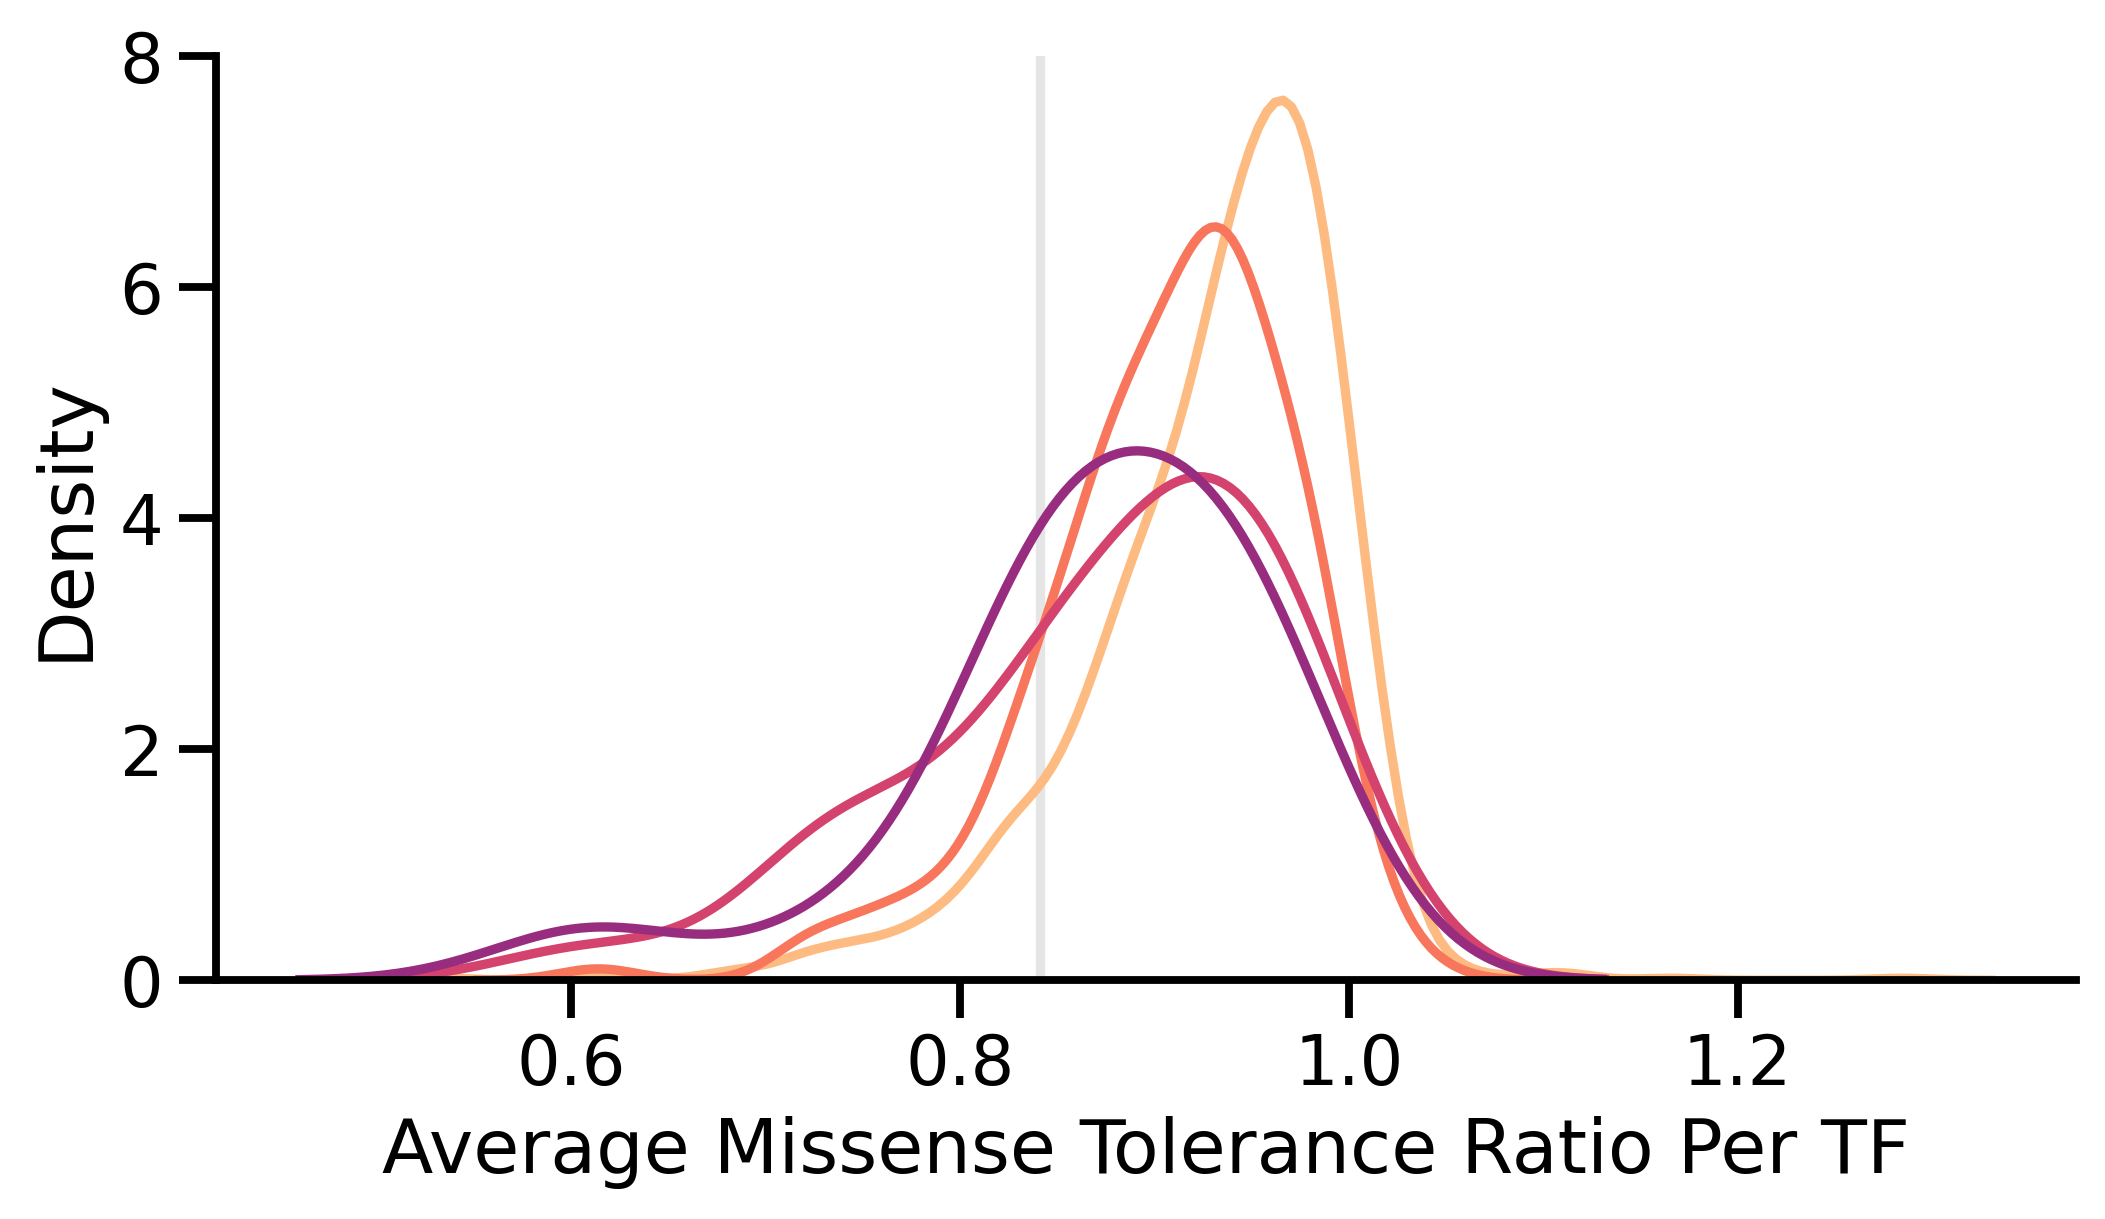

In [95]:
sns.set_context('talk')
plt.figure(figsize = (8, 4), dpi = 300)

plt.axvline(0.841, color = "gray", alpha = 0.2)

palette = sns.color_palette("magma_r")

sns.kdeplot(cds_mtr[["ENST", "MTR"]].groupby("ENST").mean()["MTR"], label = "All TFs", color = palette[0])

df = cds_mtr[cds_mtr["Activator"]]#["MTR"]
sns.kdeplot(df[["ENST", "MTR"]].groupby("ENST").mean()["MTR"], label = "Activator TFs", color = palette[1])

df = cds_mtr[cds_mtr["sfari_with_AD"]]#["MTR"]
sns.kdeplot(df[["ENST", "MTR"]].groupby("ENST").mean()["MTR"], label = "SFARI Activator TFs", color = palette[2])

df = cds_mtr[cds_mtr["hits"]]#["MTR"]
sns.kdeplot(df[["ENST", "MTR"]].groupby("ENST").mean()["MTR"], label = "SFARI Activator TF Hits", color = palette[3])

#plt.legend()
sns.despine()

plt.xlabel("Average Missense Tolerance Ratio Per TF")

In [105]:
len(lambert_TFs[lambert_TFs["sfari"] & lambert_TFs["sfari"]]["transcript"].unique())

120

In [108]:
domain_activator_SFARI_TF = domain_mtr[domain_mtr["ENST"].isin(lambert_TFs[lambert_TFs["sfari"]]["transcript"])]
domain_activator_SFARI_TF = domain_activator_SFARI_TF[domain_activator_SFARI_TF[3] != "RD"]
domain_activator_SFARI_TF

,0,1,2,3,4,5,6,ENST,8,9,10,11,12,13,14,15,MTR
0,17,4981796,4981797,DBD,NaN,.,-,ENST00000348066,17,4981796,4981797,ENST00000348066,-1,17,4981796,4981797,0.936024
1,17,4981797,4981798,DBD,NaN,.,-,ENST00000348066,17,4981797,4981798,ENST00000348066,-1,17,4981797,4981798,0.936024
2,17,4981798,4981799,DBD,NaN,.,-,ENST00000348066,17,4981798,4981799,ENST00000348066,-1,17,4981798,4981799,0.930665
3,17,4981799,4981800,DBD,NaN,.,-,ENST00000348066,17,4981799,4981800,ENST00000348066,-1,17,4981799,4981800,0.930665
4,17,4981800,4981801,DBD,NaN,.,-,ENST00000348066,17,4981800,4981801,ENST00000348066,-1,17,4981800,4981801,0.930665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1042,14,64260486,64260487,AD,NaN,.,-,ENST00000341099,14,64260486,64260487,ENST00000341099,-1,14,64260486,64260487,0.916488
1043,14,64260487,64260488,AD,NaN,.,-,ENST00000341099,14,64260487,64260488,ENST00000341099,-1,14,64260487,64260488,0.916488
1044,14,64260488,64260489,AD,NaN,.,-,ENST00000341099,14,64260488,64260489,ENST00000341099,-1,14,64260488,64260489,0.921816
1045,14,64260489,64260490,AD,NaN,.,-,ENST00000341099,14,64260489,64260490,ENST00000341099,-1,14,64260489,64260490,0.921816


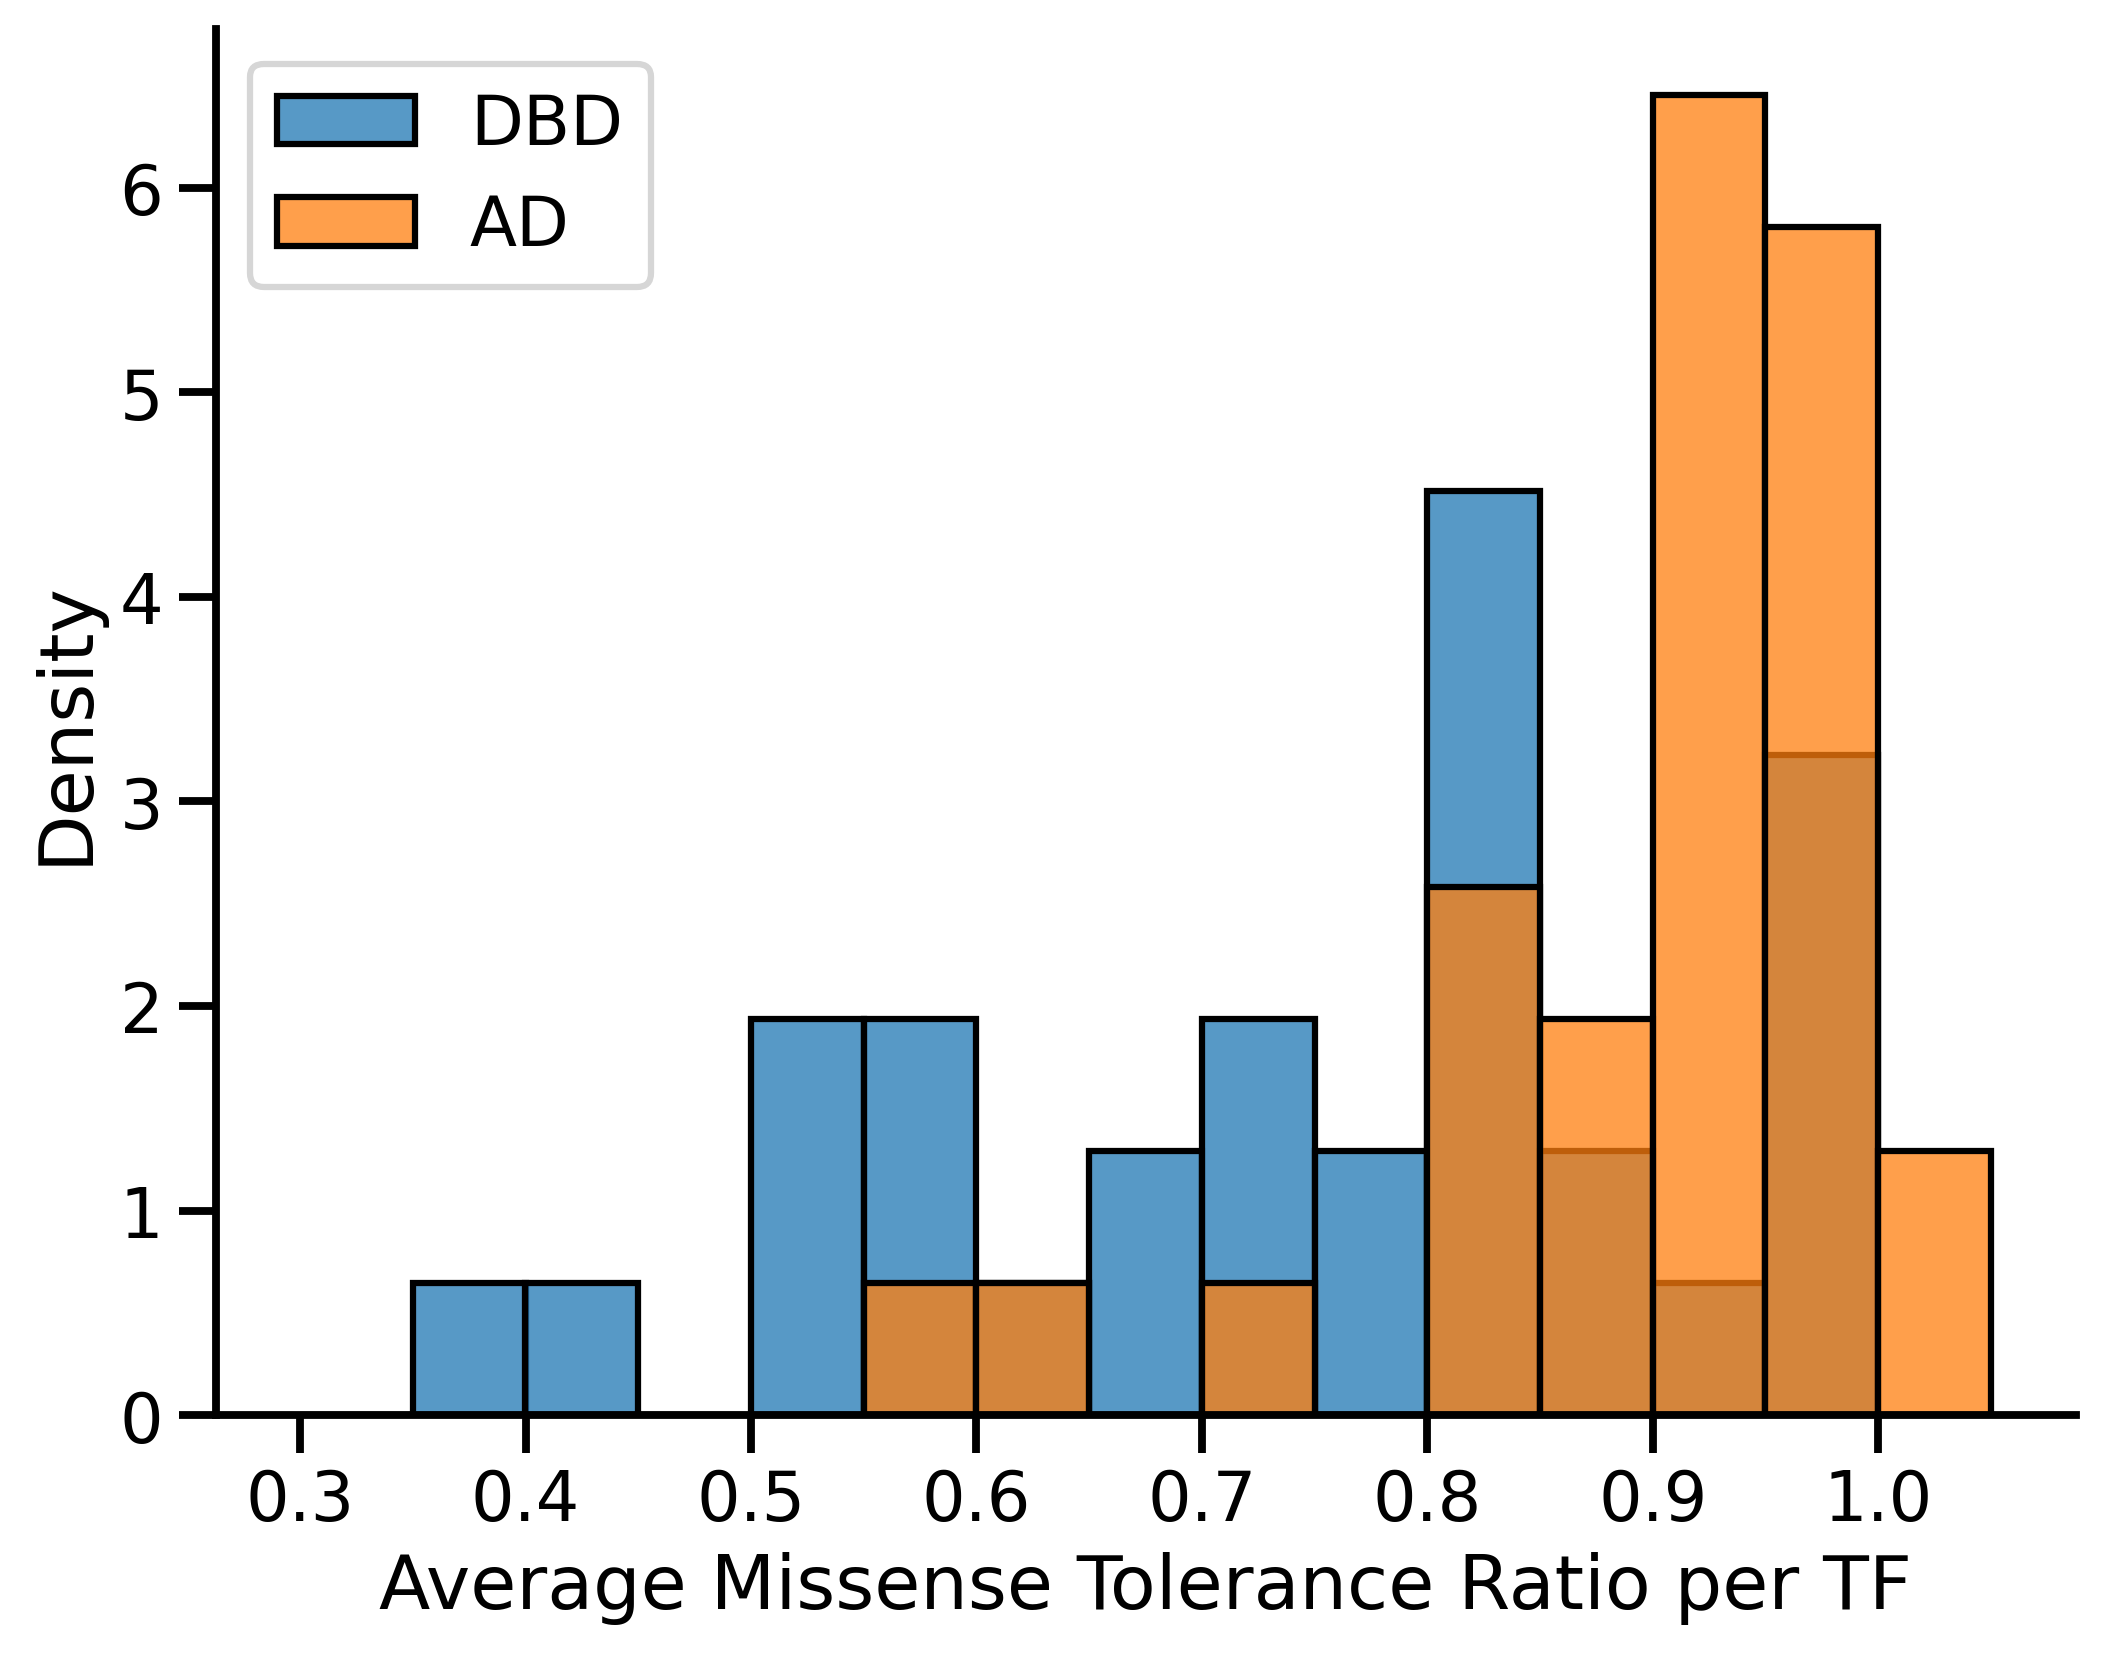

In [125]:
bins = np.arange(0.3, 1.1, 0.05)
plt.figure(figsize = (8,6), dpi = 300)

df = domain_activator_SFARI_TF[domain_activator_SFARI_TF[3] == "DBD"]
sns.histplot(df[["ENST", "MTR"]].groupby("ENST").mean()["MTR"], label = "DBD", bins = bins, stat = 'density')

df = domain_activator_SFARI_TF[domain_activator_SFARI_TF[3] == "AD"]
sns.histplot(df[["ENST", "MTR"]].groupby("ENST").mean()["MTR"], label = "AD", bins = bins, stat = 'density')

plt.xlabel("Average Missense Tolerance Ratio per TF")

plt.legend()
sns.despine()